--- Stage 1: Feedforward Neural Network on Fashion-MNIST ---

Training images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)
Vectorized training shape: (60000, 784)
Vectorized test shape: (10000, 784)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Dense Network Summary ---



--- Training Dense Network ---

--- Evaluating Dense Network ---
Dense Net Test Loss: 0.3291
Dense Net Test Accuracy: 0.8822

--- Dense Network Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.84      0.83      1000
           1       1.00      0.96      0.98      1000
           2       0.82      0.78      0.80      1000
           3       0.88      0.91      0.89      1000
           4       0.79      0.79      0.79      1000
           5       0.98      0.95      0.97      1000
           6       0.67      0.70      0.68      1000
           7       0.92      0.98      0.95      1000
           8       0.97      0.98      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


--- Dense Network Confusion Matrix ---


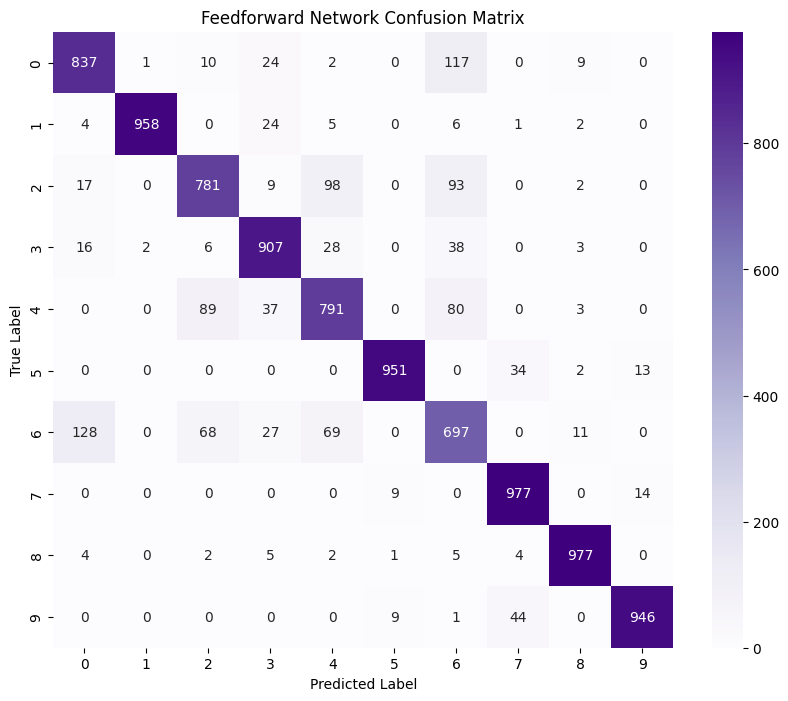

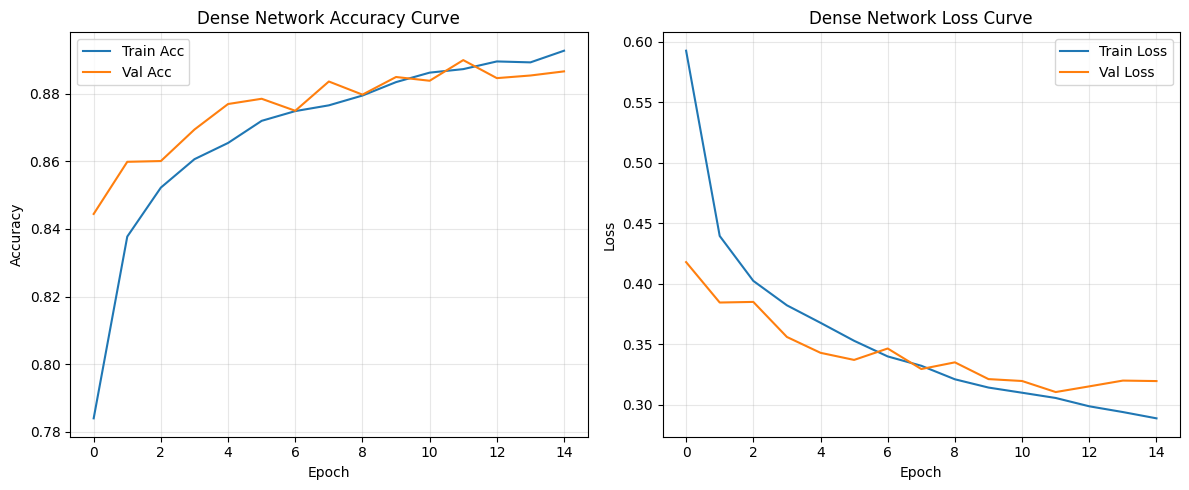


--- Stage 2: Convolutional Neural Network on MNIST ---

Digit training shape: (60000, 28, 28)
Digit test shape: (10000, 28, 28)
Reshaped training shape: (60000, 28, 28, 1)
Reshaped test shape: (10000, 28, 28, 1)

--- Convolutional Network Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Convolutional Network ---

--- Evaluating Convolutional Network ---
Conv Net Test Loss: 0.0395
Conv Net Test Accuracy: 0.9895

--- Convolutional Network Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


--- Convolutional Network Confusion Matrix ---


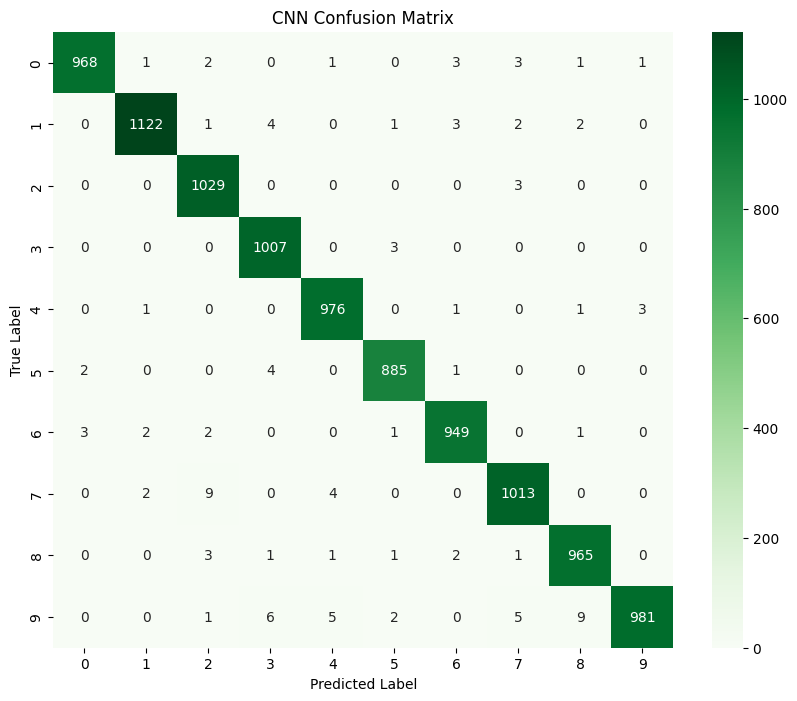

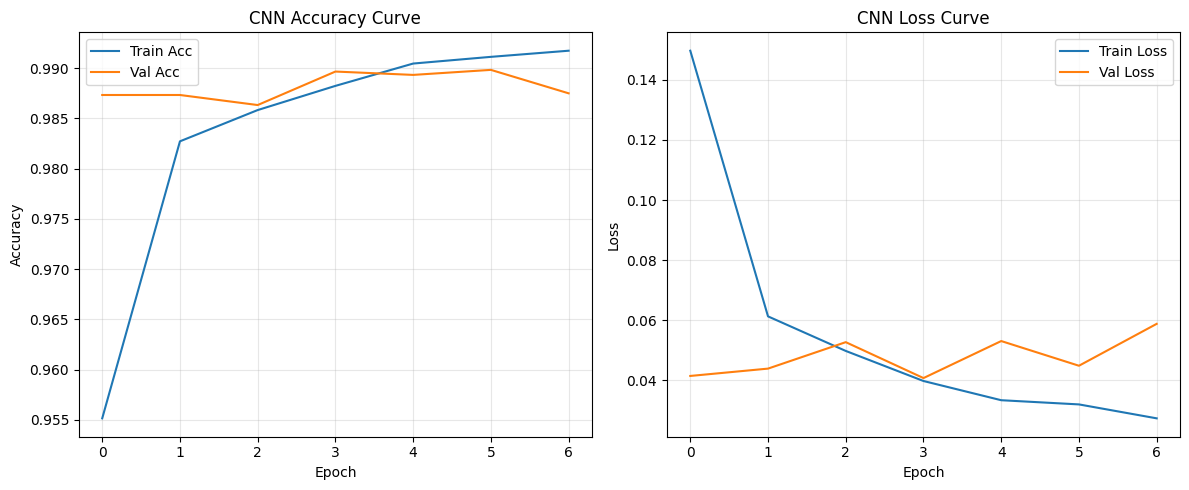


--- Sample Digit Predictions ---


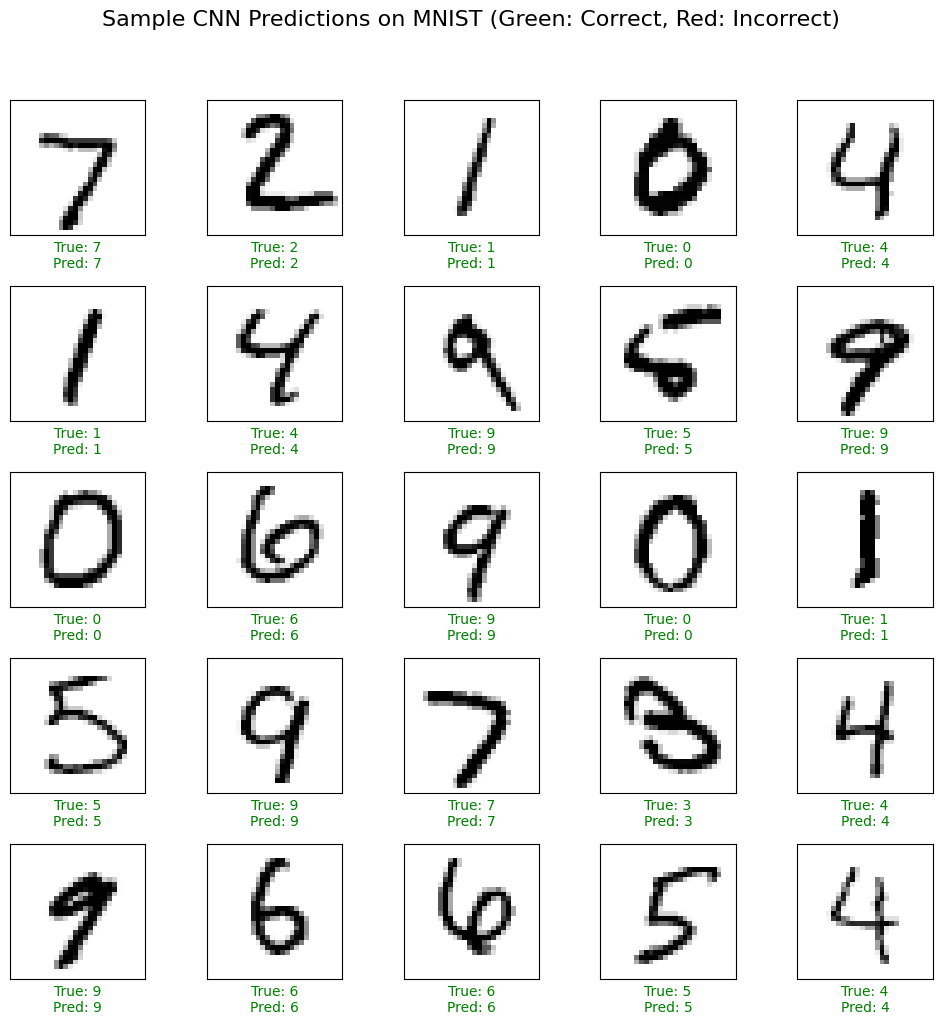

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

tf.keras.utils.disable_interactive_logging()

print("--- Stage 1: Feedforward Neural Network on Fashion-MNIST ---")

(train_imgs, train_labels), (test_imgs, test_labels) = fashion_mnist.load_data()
print("\nTraining images shape:", train_imgs.shape)
print("Test images shape:", test_imgs.shape)

train_vectors = train_imgs.reshape(-1, 784).astype('float32') / 255.0
test_vectors = test_imgs.reshape(-1, 784).astype('float32') / 255.0
print("Vectorized training shape:", train_vectors.shape)
print("Vectorized test shape:", test_vectors.shape)

dense_net = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

dense_net.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print("\n--- Dense Network Summary ---")
dense_net.summary()

stop_early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\n--- Training Dense Network ---")
dense_history = dense_net.fit(train_vectors, train_labels, epochs=15,
                               validation_split=0.15, callbacks=[stop_early], verbose=1)

print("\n--- Evaluating Dense Network ---")
dense_loss, dense_acc = dense_net.evaluate(test_vectors, test_labels, verbose=0)
print(f"Dense Net Test Loss: {dense_loss:.4f}")
print(f"Dense Net Test Accuracy: {dense_acc:.4f}")

dense_preds = np.argmax(dense_net.predict(test_vectors), axis=-1)
print("\n--- Dense Network Classification Report ---")
print(classification_report(test_labels, dense_preds))

print("\n--- Dense Network Confusion Matrix ---")
dense_cm = confusion_matrix(test_labels, dense_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(dense_cm, annot=True, fmt="d", cmap="Purples", cbar=True)
plt.title("Feedforward Network Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(dense_history.history['accuracy'], label='Train Acc')
plt.plot(dense_history.history['val_accuracy'], label='Val Acc')
plt.title('Dense Network Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(dense_history.history['loss'], label='Train Loss')
plt.plot(dense_history.history['val_loss'], label='Val Loss')
plt.title('Dense Network Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Stage 2: Convolutional Neural Network on MNIST ---")

(digit_train_imgs, digit_train_labels), (digit_test_imgs, digit_test_labels) = mnist.load_data()
print("\nDigit training shape:", digit_train_imgs.shape)
print("Digit test shape:", digit_test_imgs.shape)

digit_train_imgs = digit_train_imgs.reshape(-1, 28, 28, 1).astype('float32') / 255.0
digit_test_imgs = digit_test_imgs.reshape(-1, 28, 28, 1).astype('float32') / 255.0
print("Reshaped training shape:", digit_train_imgs.shape)
print("Reshaped test shape:", digit_test_imgs.shape)

num_digit_classes = 10

conv_net = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_digit_classes, activation='softmax')
])

conv_net.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("\n--- Convolutional Network Summary ---")
conv_net.summary()

print("\n--- Training Convolutional Network ---")
conv_history = conv_net.fit(digit_train_imgs, digit_train_labels, epochs=12,
                             validation_split=0.1, callbacks=[stop_early], verbose=1)

print("\n--- Evaluating Convolutional Network ---")
conv_loss, conv_acc = conv_net.evaluate(digit_test_imgs, digit_test_labels, verbose=0)
print(f"Conv Net Test Loss: {conv_loss:.4f}")
print(f"Conv Net Test Accuracy: {conv_acc:.4f}")

conv_preds = np.argmax(conv_net.predict(digit_test_imgs), axis=-1)
print("\n--- Convolutional Network Classification Report ---")
print(classification_report(digit_test_labels, conv_preds))

print("\n--- Convolutional Network Confusion Matrix ---")
conv_cm = confusion_matrix(digit_test_labels, conv_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(conv_cm, annot=True, fmt="d", cmap="Greens", cbar=True)
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(conv_history.history['accuracy'], label='Train Acc')
plt.plot(conv_history.history['val_accuracy'], label='Val Acc')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(conv_history.history['loss'], label='Train Loss')
plt.plot(conv_history.history['val_loss'], label='Val Loss')
plt.title('CNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Sample Digit Predictions ---")
digit_class_names = [str(i) for i in range(10)]
plt.figure(figsize=(10, 10))
for idx in range(25):
    plt.subplot(5, 5, idx + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(digit_test_imgs[idx].reshape(28, 28), cmap=plt.cm.binary)
    actual = digit_test_labels[idx]
    predicted = conv_preds[idx]
    label_color = 'green' if actual == predicted else 'red'
    plt.xlabel(f"True: {digit_class_names[actual]}\nPred: {digit_class_names[predicted]}", color=label_color)
plt.suptitle("Sample CNN Predictions on MNIST (Green: Correct, Red: Incorrect)", y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()